**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [60]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [61]:
import io

# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
request = requests.get(url).content
stanford_df = pd.read_csv(io.BytesIO(request))

stanford_df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [62]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print(df.head(), '\n')

# TODO: Display the data types of each column
print(df.dtypes, '\n')


# TODO: Display summary statistics of the numerical columns
df.describe()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S   



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({
    1: 'First',
    2: 'Second',
    3: 'Third'
})

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
df.fillna({'Cabin': 'Unknown'}, inplace=True)
df['CabinCategory'] = df['Cabin'].astype(str).str[0]

# TODO: Handle missing values in the 'Age' column (use mean age)
mean_age = df['Age'].mean()
df.fillna({'Age': mean_age}, inplace=True)

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
df['Family'] = df['SibSp'] + df['Parch']


In [65]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]

# TODO: Find passengers with the largest family size
largest_family_passengers = df[df['Family'] == df['Family'].max()]

print('Highest fare passengers: \n', highest_fare_passengers, '\n')
print('\nLargest familf passengers:\n', largest_family_passengers)

Highest fare passengers: 
      PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292      Unknown        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

    PclassCategory CabinCategory  Family  
258          First             U       0  
679          First             B       1  
737          First             B       0   


Largest familf passengers:
      PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas Henry    male   
18

In [66]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
names_series = df['Name']

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]

# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df['Age'] > 50]

print('Passenger names:\n', names_series, '\n')
print('\nPassenger names and ages:\n', names_ages_df, '\n')
print('\nOlder passengers:\n', older_passengers)

Passenger names:
 0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object 


Passenger names and ages:
                                                   Name        Age
0                              Braund, Mr. Owen Harris  22.000000
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.000000
2                               Heikkinen, Miss. Laina  26.000000
3         Futrelle, Mr

In [67]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df = df.groupby(['Sex', 'Pclass'])['Survived'].mean().to_frame('SurvivalRate')

multi_index_df

SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.135447

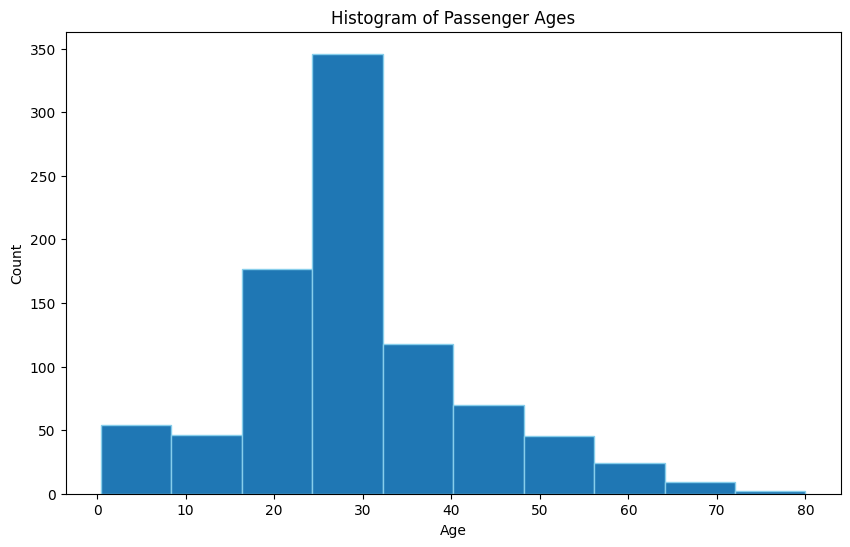

In [68]:
# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], edgecolor='skyblue')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

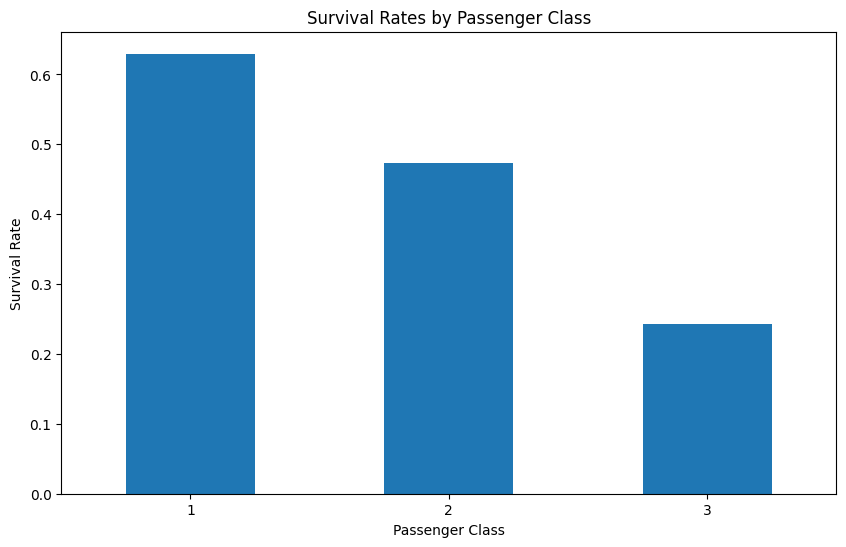

In [69]:
# Task 7: Visualizations

# TODO: Create a bar plot of survival rates by passenger class
survival_rates = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(10, 6))
survival_rates.plot(kind='bar')
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

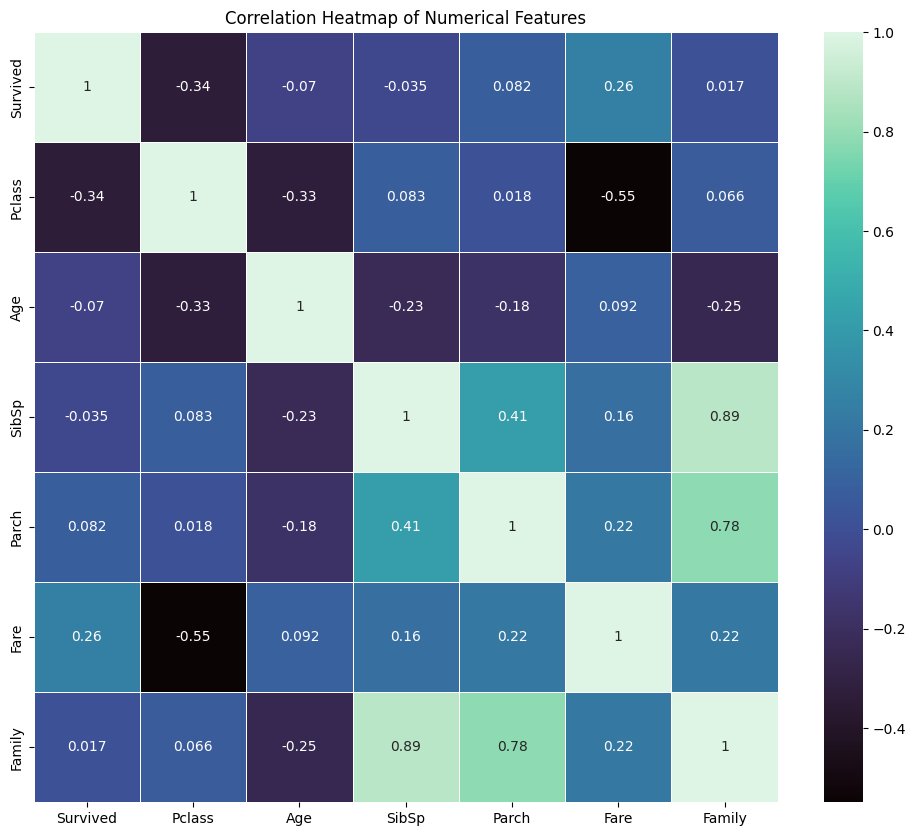

In [70]:
# Task 7: Visualizations

# TODO: Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family']].corr()

sns.heatmap(corr, annot=True, cmap='mako', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

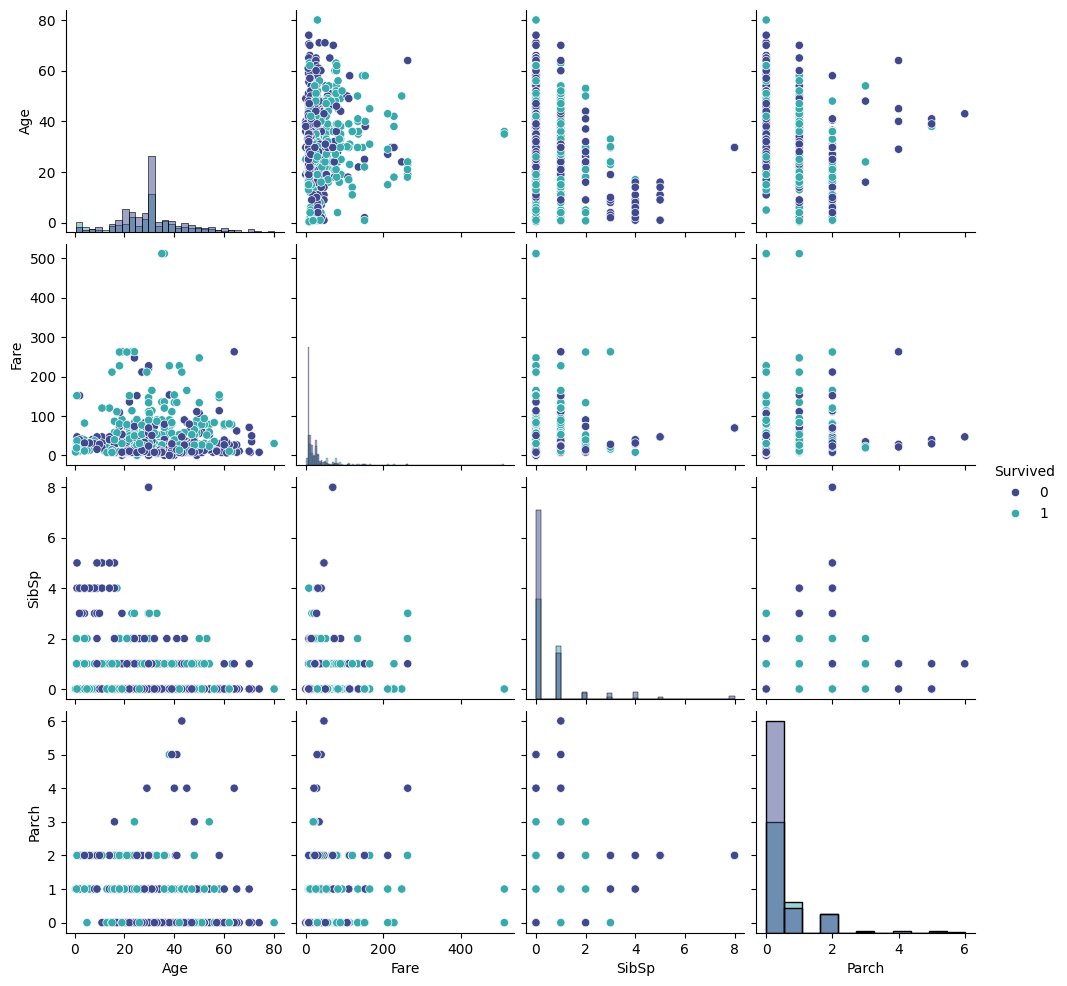

In [71]:
# Task 7: Visualizations

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(
    df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']],
    hue='Survived',
    palette='mako',
    diag_kind='hist'
)
plt.show()

In [72]:
# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()

# TODO: Calculate and display survival rates by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean()

display(survival_by_sex)
print('\n')
display(survival_by_class)

,Survived
Sex,
female,0.742038
male,0.188908


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


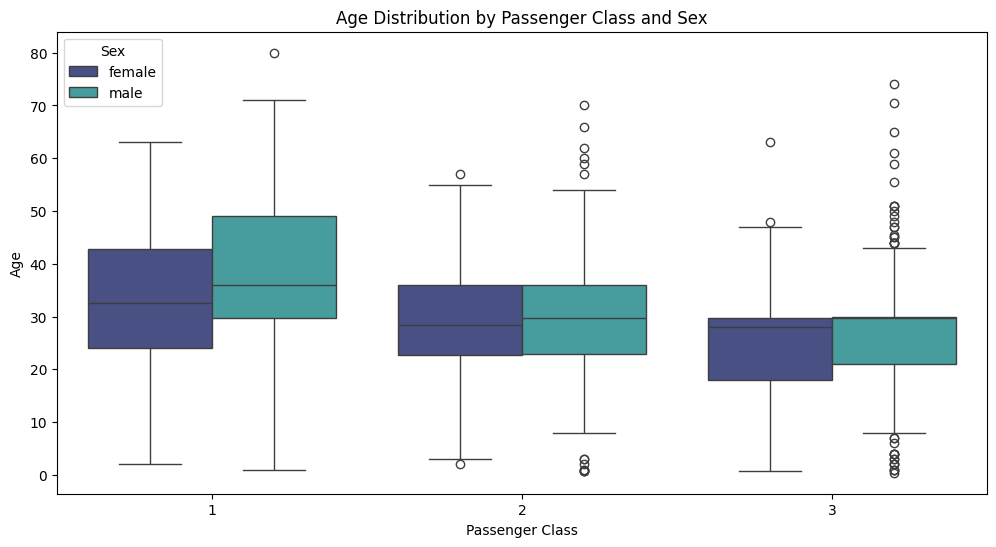

In [73]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex', palette='mako')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(title='Sex')
plt.show()

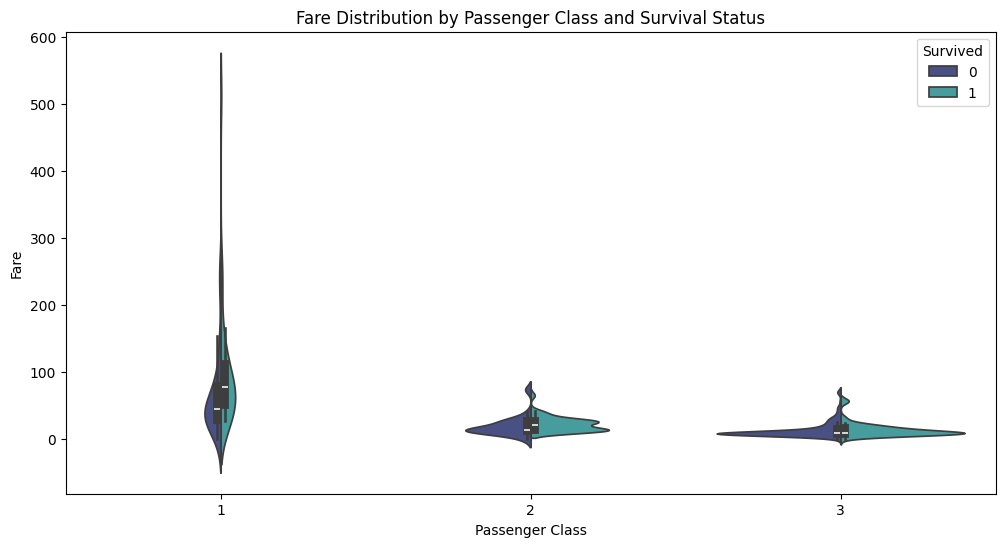

EDA tasks completed.


In [74]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived',
    split=True,
    palette='mako'
)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.legend(title='Survived')
plt.show()

print("EDA tasks completed.")